# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b>03 - COMPLEX - CNN - MNIST - B287</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>For more recent updates, Don't Forget to Follow us on:</b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [Whatsapp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [Linkedin](https://www.linkedin.com/company/techproeducation/mycompany/) |

* This NB for compare ANN, basic and complex CNN models on same data set.

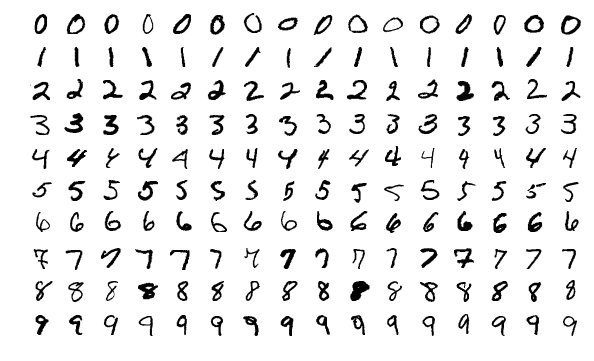

In this notebook, we are going to dive into the MNIST (Modified National Institute of Standards and Technology) database. It can be said that the MNIST handprinted character image dataset is the “Hello World” implementation for machine learning, and the dataset is used as a worldwide machine learning benchmark. It is an extremely good database for people who want to try machine learning techniques and pattern recognition methods on real-world data while spending minimal time and effort on data preprocessing and formatting. Its simplicity and ease of use are what make this dataset so widely used and deeply understood. Therefore, the goal of this tutorial is to show you how this dataset can be used in a digits recognition example using Convolutional Neural Network (CNN), which achieves a high classification accuracy on the test dataset. On a larger perspective, we will emphasize on MNIST’s importance and impact in the world of machine learning.

MNIST is a large database of small, square 28x28 pixel grayscale images of handwritten single digits between 0 and 9. It consists of a total of 70,000 handwritten images of digits, with the training set having 60,000 images and the test set having 10,000. All images are labeled with the respective digit that they represent. There are a total of 10 classes of digits (from 0 to 9).

Our task is to classify a given image of a handwritten digit into one of 10 classes representing integer values from 0 to 9, inclusively using a CNN that will be able to recognize the handwritten digits. CNN is a type of deep neural network commonly used for computer vision applications. So we will build an image classifier TensorFlow’s Keras API on the MNIST dataset. Keras is a Python library and is highly recommended for beginners due to its smooth learning curve. It is very commonly used in implementing neural networks. 

In [1]:
import pandas as pd
import seaborn as sns
import tensorflow as tf                       
import numpy as np                           
import matplotlib.pyplot as plt               
%matplotlib inline

# Hide all warnings
import warnings
warnings.filterwarnings("ignore")

# Hide deprecated warnings in Keras and TensorFlow
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Load Data

In [2]:
from tensorflow.keras.datasets.mnist import load_data    # To load the MNIST digit dataset

It is used to load the MNIST dataset from the Keras module under the TensorFlow library. MNIST is a dataset containing handwritten digits and is often used for training machine learning models. The load_data function downloads and loads the dataset. For this code to work, the TensorFlow library must be installed and set up on your computer.

In [3]:
(X_train, y_train) , (X_test, y_test) = load_data()      # Loading data

It is used to separate the data loaded from the MNIST dataset into training and test datasets. The load_data() function loads the MNIST dataset and in this line it is separated into training data (X_train, y_train) and test data (X_test, y_test). X_train and X_test data are 1D tensors containing the pixel values of the images. y_train and y_test data are 1D tensors containing the correct class labels of the images.

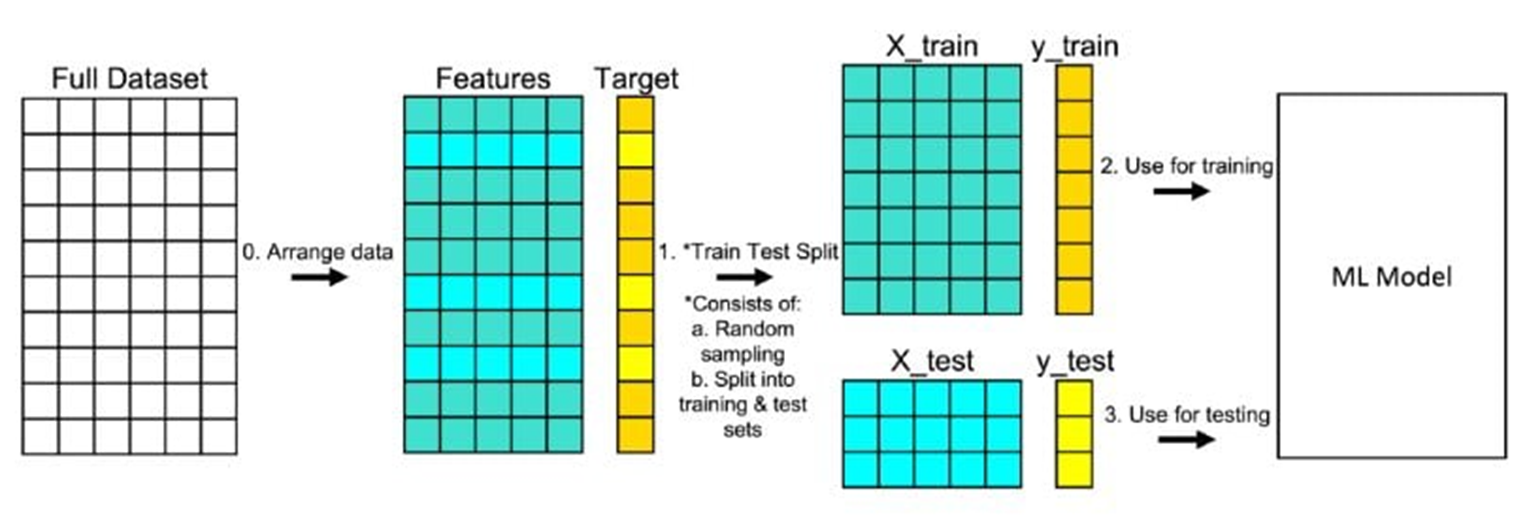

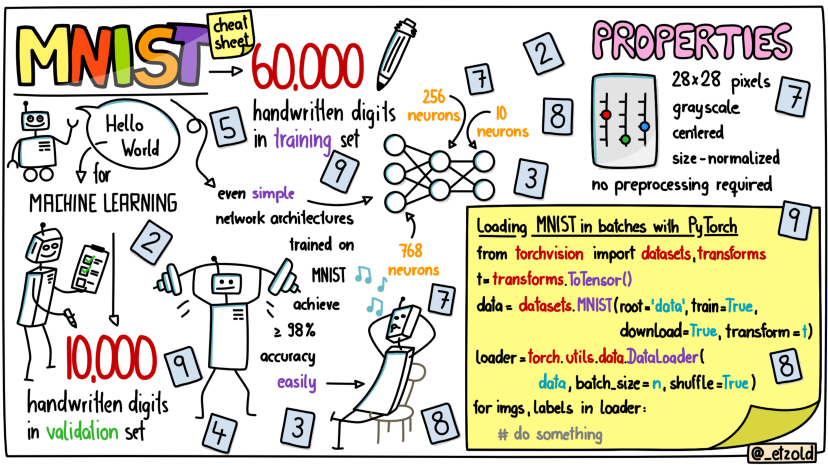

In [4]:
print(X_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


Prints the shape of the x_train and y_train data. The x_train.shape statement returns the shape of the training data as a 1D tensor. The first dimension of this tensor is the number of training examples. The second and third dimensions are arranged as the height and width of the images. The y_train.shape statement returns the shape of the y_train data as a 1D tensor. The dimension of this tensor is the number of training examples. Each element contains the correct class label for the matched example. The output of this code specifies the shape of the training data and the shape of its labels.

In [5]:
print(X_test.shape, y_test.shape)

(10000, 28, 28) (10000,)


The X_test tensor contains images of test samples from the MNIST dataset. Since these images are grayscale, each has only one channel and therefore no third dimension. Therefore, the X_test tensor is (10000, 28, 28), meaning that 10,000 test samples each contain a black and white image of size 28x28.

However, if the images were color (RGB), each pixel would have red, green and blue channels. In this case, the X_test tensor would have a third dimension and would be (10000, 28, 28, 3).

The MNIST dataset contains handwritten images of digits. The classification of these images, i.e., determining which digit corresponds to which image, is an example of a set of classification problems. In the MNIST dataset, each image contains only one digit. Therefore, each image belongs to only one class, and the y_train and y_test tensors contain a single class label to which each image belongs.

The size of the y_train tensor is the number of samples in the training set. For example, if there are 50,000 samples in the training set, the y_train tensor will be of size 50,000. Each element indicates the correct class label of the matching example. The y_train tensor is one-dimensional because each element contains only one class label. Each element contains information such as, for example, “This image represents the digit 5.” Therefore, the y_train tensor can be described in a one-dimensional way.

In [6]:
print("There are ", len(X_train), "images in the training dataset")     
print("There are ", len(X_test), "images in the test dataset")   

There are  60000 images in the training dataset
There are  10000 images in the test dataset


In [7]:
# Checking the shape of one image
X_train[65].shape

(28, 28)

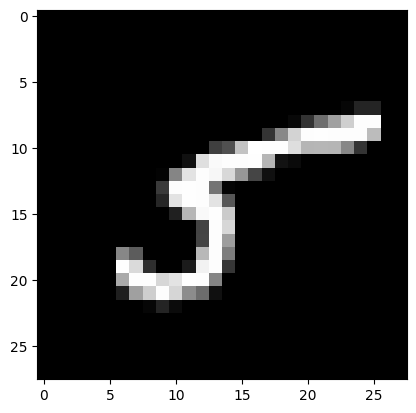

In [8]:
image_65 = X_train[65].reshape(28, 28)
plt.imshow(image_65, cmap='gray');

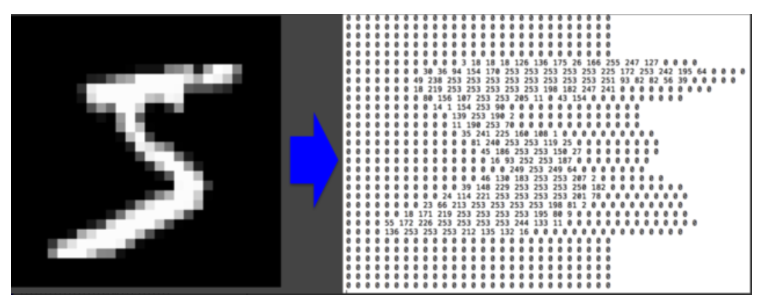

In [9]:
X_train[169]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  42, 235, 255,  84,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  15,
        132, 208, 253, 253, 171, 108,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

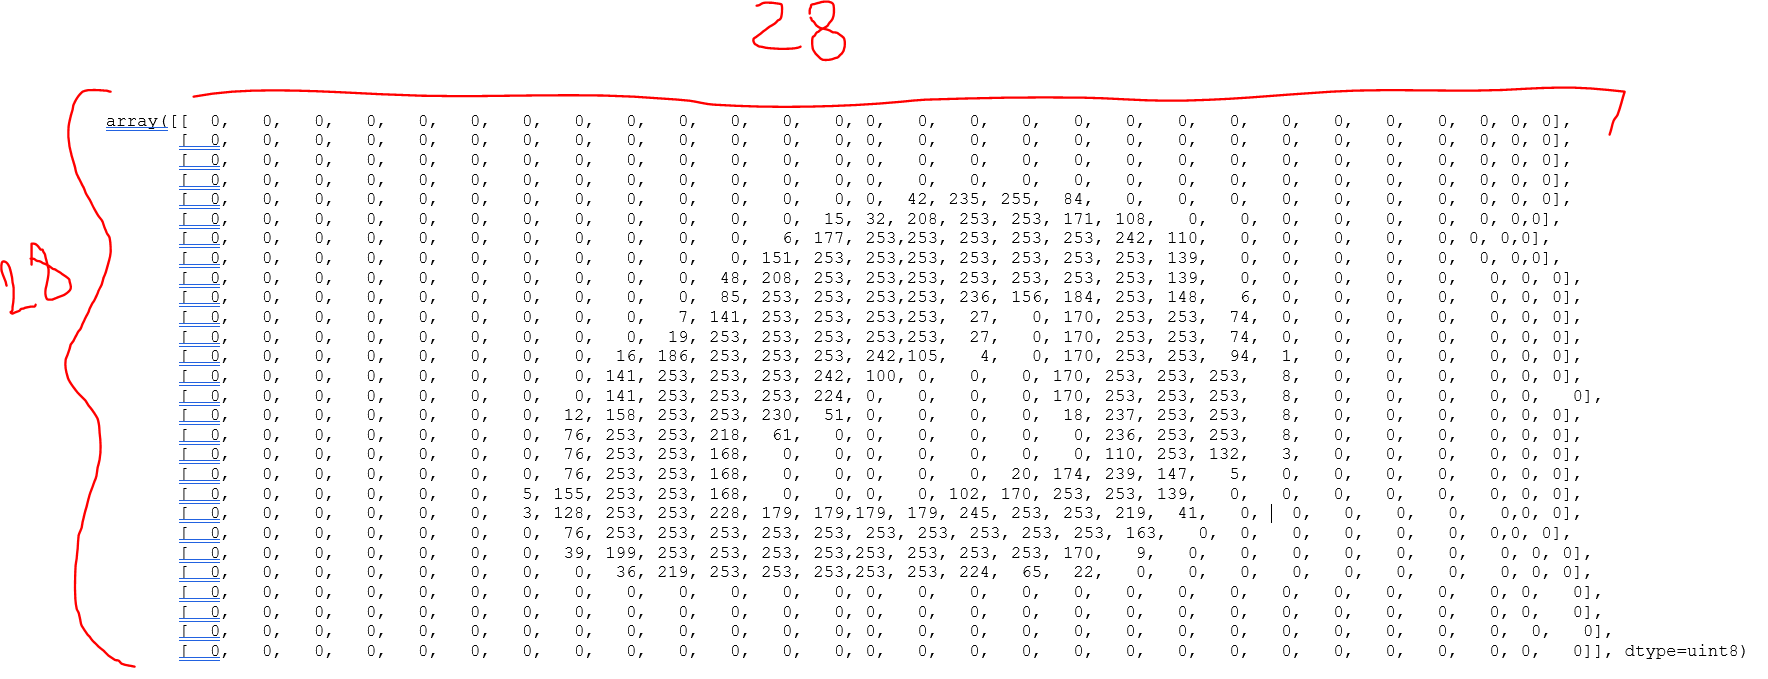

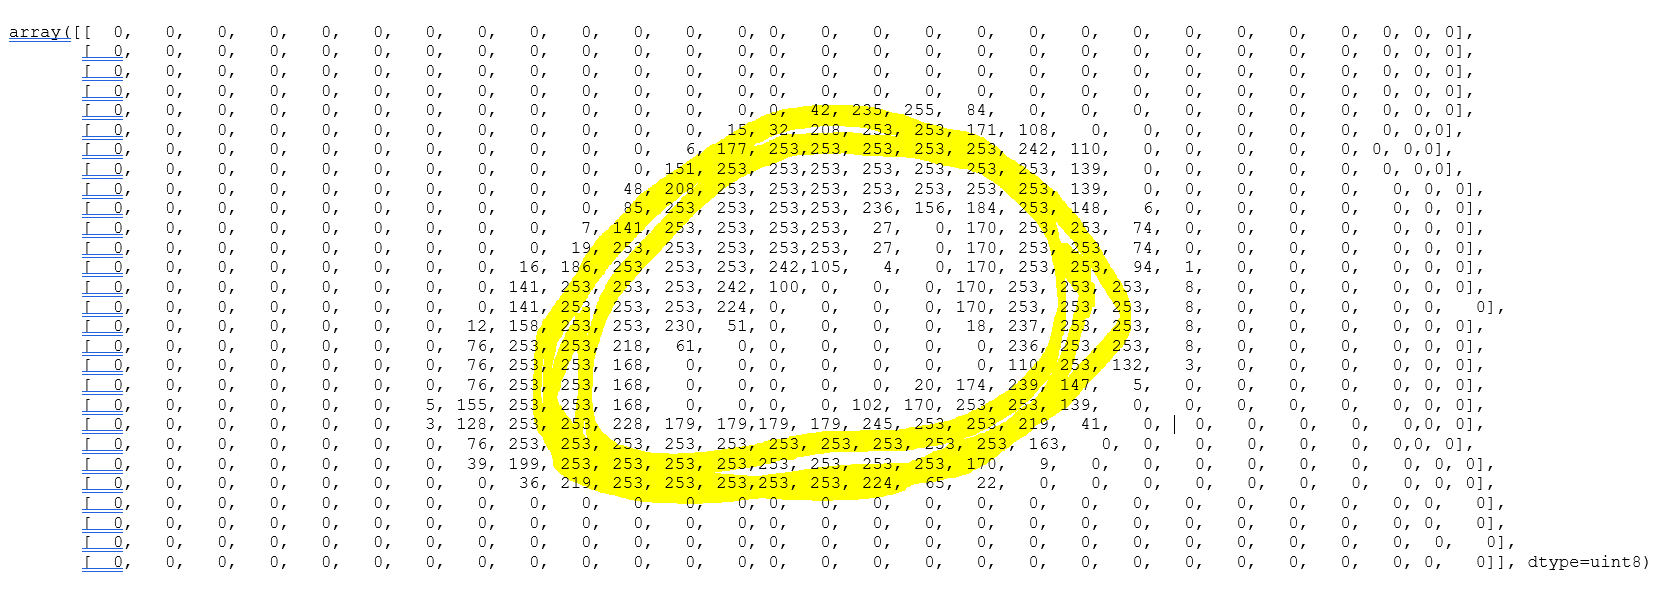

In [10]:
import matplotlib.pyplot as plt

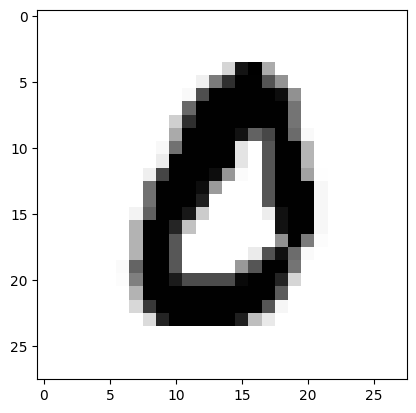

In [11]:
plt.imshow(X_train[169], cmap= plt.cm.binary);

**cmap= plt.cm.binary** parametresi, specifies a color map used to obtain a black and white image.

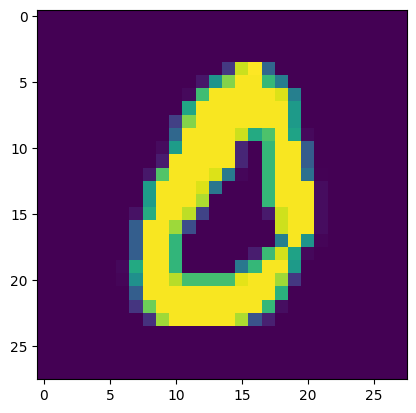

In [12]:
plt.imshow(X_train[169]); # if you use just "plt.imshow" it will gives in colourfull (RGB). 

In [13]:
X_train[768] # Numerical version

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   7,
         24,  24,  77,  98, 139, 139, 192, 245, 139, 139,  25,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  30, 187,
        253, 253, 254, 253, 253, 253, 253, 254, 224, 207,  37,   0,   0,
          0,   0],
       [  

In [14]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

The following od block creates a subsample of 3 rows and 6 columns randomly selected from the MNIST dataset. It then displays the label (y_train) and image (X_train) of each sample in the subsample.

The line f, ax = plt.subplots(3, 6, figsize=(12,5),... creates a subplot of 3 rows and 6 columns for the subsample and stores it in the variable ax. The gridspec_kw argument sets the spacing between the rows and columns of the subplot. The squeeze=True argument removes the extra dimension of the subplots and leaves only the row and column dimensions.

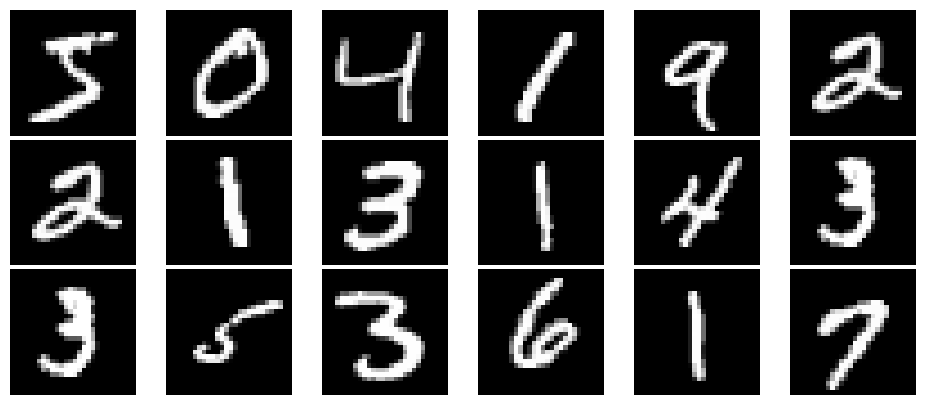

In [15]:
num_rows, num_cols = 3, 6                                       # Datadan 3 tane row, 6 tane column sectik.
f, ax = plt.subplots(3, 6, figsize=(12,5),
                     gridspec_kw={'wspace':0.04, 'hspace':0.03}, 
                     squeeze=True)

for r in range(num_rows):
    for c in range(num_cols):
      
        image_index = r * 5 + c
        ax[r,c].axis("off")
        ax[r,c].imshow( X_train[image_index], cmap='gray')
plt.show()
plt.close()

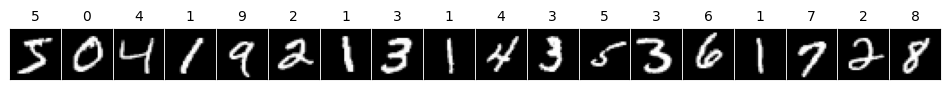

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=18, figsize=(12,5),
                         gridspec_kw={'wspace':0.04, 'hspace':0.03}, 
                         squeeze=True)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_xticks([]), ax.set_yticks([])
    ax.set_title(str(y_train[i]), fontsize=10)
    
plt.tight_layout()
plt.show()

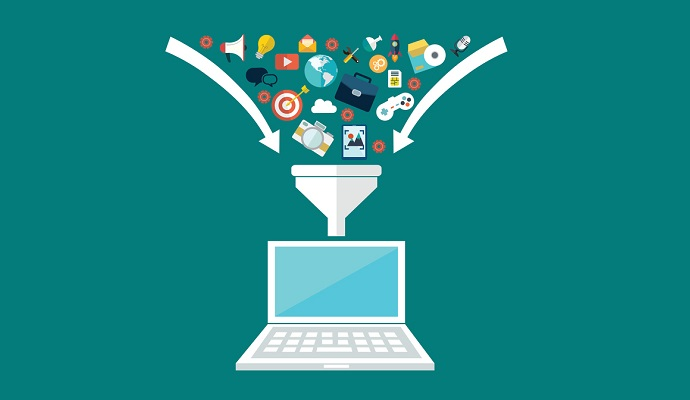

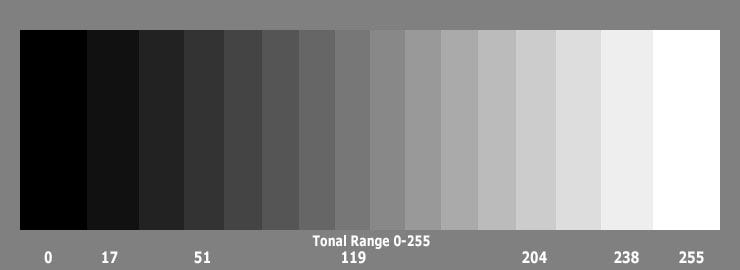

# Data Preprocessing

In [17]:
X_train[9].min()

np.uint8(0)

In [18]:
X_train[9].max()

np.uint8(255)

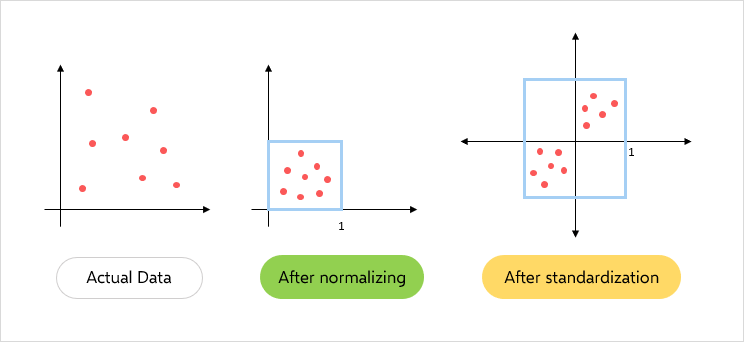

## Normalisation

In [19]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

This code block is used to convert the pixel values of images in the MNIST dataset from the range 0-255 to the range 0-1. The first two lines convert the data type of the numpy arrays X_train and X_test to float32. The next two lines divide each pixel by its maximum value of 255, so that each pixel is represented as a decimal number between 0 and 1. This can help the network learn better and make the data easier to process.

In [20]:
X_train[17]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [21]:
X_train[17].min()

np.float32(0.0)

In [22]:
X_train[17].max()

np.float32(1.0)

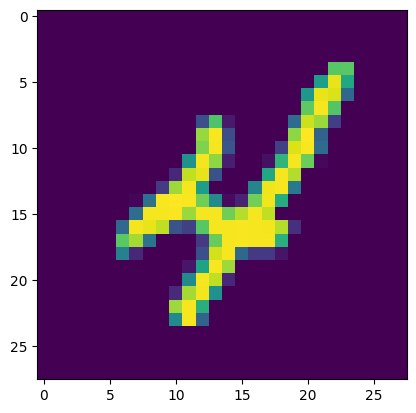

In [23]:
plt.imshow(X_train[9]);

## Reshape the Data For CNN (Create Tensors)

In [24]:
X_train = X_train.reshape(X_train.shape[0],28, 28, 1) 
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

The above code block reshapes the size of the images in the MNIST dataset accordingly. Each image in the MNIST dataset is of 28x28 pixels. However, since the input data for the CNN model needs to be in the form of a 3D tensor, each image is converted to a tensor of size 28x28x1.

This process is done using the reshape() function. Here, the arrays X_train and X_test contain the training and test data respectively. X_train.shape[0] and X_test.shape[0] represent the number of samples in each array. Each of these samples is an image of size 28x28.

In the reshape() function, new dimensions are specified for each sample. Using X_train.shape[0] and X_test.shape[0], the number of samples in each array is determined. That is, each sample is converted to a tensor of size 28x28x1.

As a result, the arrays X_train and X_test each contain 3D tensors of size 28x28x1. These tensors have a suitable shape that can be used as input to the CNN model.

It is used to make the images in the MNIST dataset suitable for convolutional neural networks (CNNs). The reshape function transforms each image in the X_train and X_test numpy arrays into 4D tensors with height and width dimensions of 28x28 pixels and only one color channel.

This transformation conforms to the tensor format that CNNs accept as input. In 4D tensors, the first dimension represents the number of images, the second and third dimensions represent the image height and width, and the fourth dimension represents the number of color channels in each pixel (in this example, there is only 1 color channel).

In [25]:
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

If X_train were a single matrix of size 28x28 (shape=(60000, 28, 28)), it would not be possible to fit it into a CNN model because CNN models expect a 4-dimensional data structure. Therefore, by reshaping, X_train was transformed into a 4-dimensional data structure (60000, 28, 28, 1).

In [26]:
X_train

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

* X_train & X_test are in 4D TENSOR format now.

* You can count number of ]]]] for understanding dimension.

In [27]:
X_train[777].shape

(28, 28, 1)

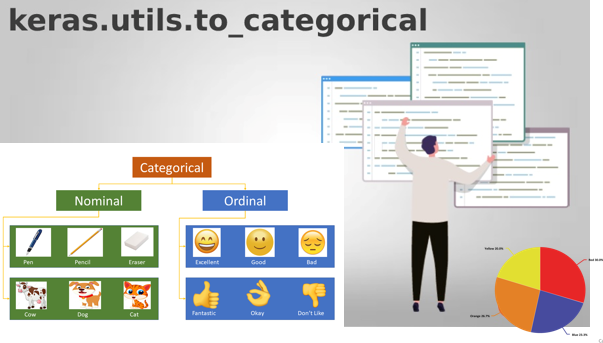

## Output Format

Output should be in vectorial format.

In [28]:
# Current Output Format
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [29]:
y_train[115]

np.uint8(4)

* We are using second method (by adding "**sparse**" to **model.compile(loss='sparse_categorical_crossentropy'**), whics easier than first one. 

In [30]:
# from tensorflow.keras.utils import to_categorical

In [31]:
"""Y_train = to_categorical(y_train, 10) 
Y_test = to_categorical(y_test, 10)
Y_test.shape"""

'Y_train = to_categorical(y_train, 10) \nY_test = to_categorical(y_test, 10)\nY_test.shape'

In [32]:
# Y_train[115]

In [33]:
# Y_train[715]

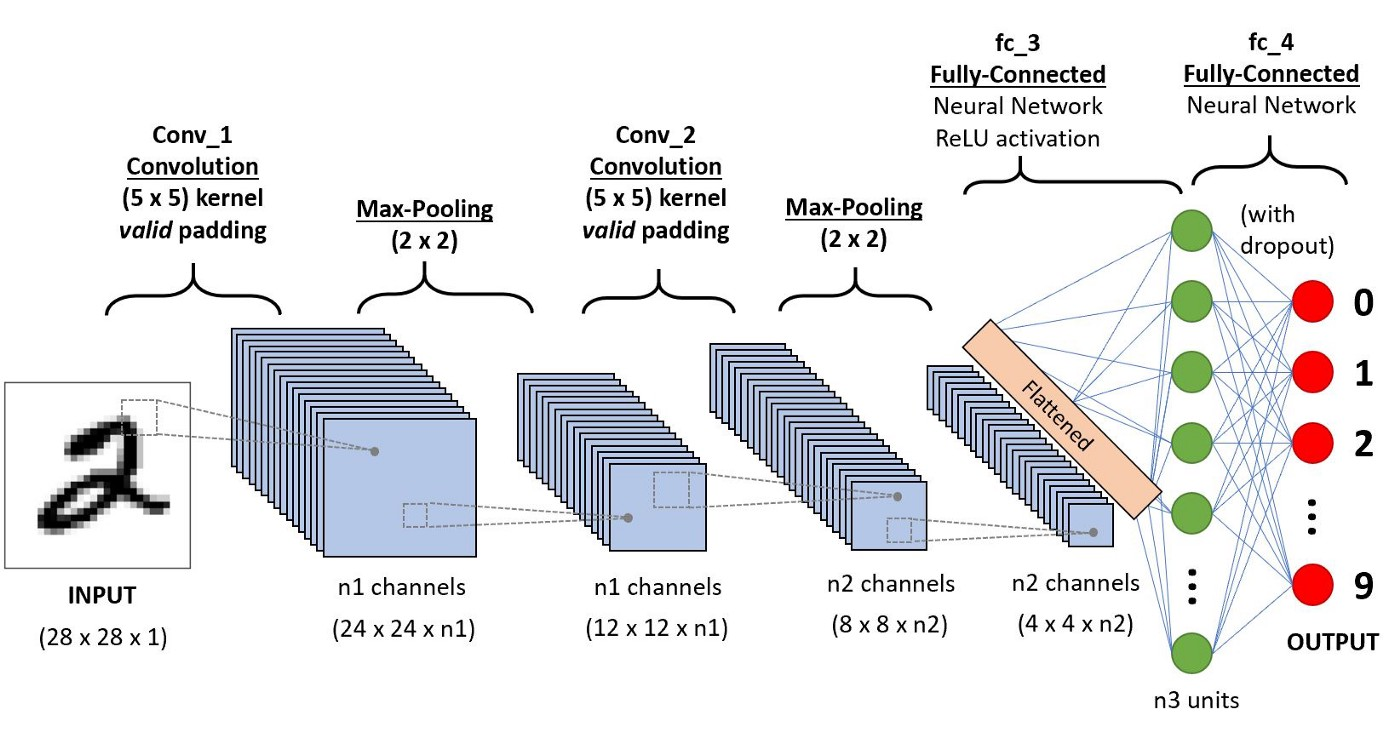

## Set the CNN Architecture

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout

Here, the term "**2D**" is used to indicate that we will be processing **two-dimensional images**. So, this is specifically used for Convolutional Neural Networks (CNN) which are used in image processing applications. **CNNs are a deep learning architecture that allows extracting features from image data using 2D filters**. Therefore, **CNNs usually use 2D convolution**, **2D Max Pooling**, and **2D data formats**.

This indicates that the data to be used in the **neural network is 2D**. In this case, it is verified that it has dimensions of 28x28 pixels and is expressed as 2D. The **3D** expression is used for 3D data types, such as **video**.

In [35]:
model = Sequential()

# 1st Convolutional layer
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Batch Normalization # Make faster the model, and helps solving overfitting problem
model.add(BatchNormalization())

# Dropout (dropout ratio: 0.25) # Drop the filters ; Helps solving overfitting problem
model.add(Dropout(0.25))

#---------------------------

# 2nd Convolutional layer
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu')) # 64 --> Focus on more detail 

# MaxPooling
model.add(MaxPooling2D(pool_size=(2, 2)))

# Batch Normalization ekleyin
model.add(BatchNormalization())

# Dropout ekleyin (dropout oranı: 0.25)
model.add(Dropout(0.25))

#--------------------------

# FUlly Conntected Layers
# Flatten
model.add(Flatten())

# ANN; There is 1 hiden layer
# 1st hidden layer
model.add(Dense(128, activation='relu'))

# Batch Normalisation 
model.add(BatchNormalization())

# Dropout (dropout ratio: 0.5) # Drop the neurons  
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Modeli derleme
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

Filter = 32 meaning; Produce 32 feature (different location i.e. lag, arm, head, tail, etc.) map from an image.
If we use Filter = 64, it will foces each half of lag, arm, etc.

The input_shape parameter is required to specify the input data size. If this parameter is not specified in the first layer of the model, a data size mismatch error will be received during model training. Therefore, the input_shape parameter must be specified in the first layer of the model.

We have **225,482 parameters**. It was **701,578** at "**Basic CNN**". It decreased thanks to **batch normalization** and **dropout**s.  

## Early Stop

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

In [37]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

##  Fit (Train) the Model

In [38]:
model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_test,y_test),callbacks=[early_stop])


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8903 - loss: 0.3570 - val_accuracy: 0.9826 - val_loss: 0.0545
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9736 - loss: 0.0868 - val_accuracy: 0.9860 - val_loss: 0.0400
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9770 - loss: 0.0748 - val_accuracy: 0.9868 - val_loss: 0.0378
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9805 - loss: 0.0645 - val_accuracy: 0.9895 - val_loss: 0.0308
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9832 - loss: 0.0553 - val_accuracy: 0.9915 - val_loss: 0.0251
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9851 - loss: 0.0468 - val_accuracy: 0.9917 - val_loss: 0.0268
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9849 - loss: 0.0474 - val_accuracy: 0.9920 - val_loss: 0.0232
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9857 - loss: 0

**Attention!:** When **batch size** is not specified, **32** is used by **default**. Therefore, **even if you write batch_size=None** instead of **batch_size=32**, the **same batch size** will be used. However, since this causes ambiguity, it is **recommended to specify the batch size**.

In [39]:
model.metrics_names          # Modelde metrics

['loss', 'compile_metrics']

In [40]:
model.history.history        # Loss and accuracy history of the model in training

{'accuracy': [0.9420666694641113,
  0.9743499755859375,
  0.9777833223342896,
  0.9808833599090576,
  0.9828000068664551,
  0.984749972820282,
  0.9847833514213562,
  0.9861166477203369,
  0.9868000149726868,
  0.9884499907493591],
 'loss': [0.1885518729686737,
  0.08474854379892349,
  0.0712864026427269,
  0.06209743022918701,
  0.05665759742259979,
  0.049389515072107315,
  0.04833455756306648,
  0.043900683522224426,
  0.043108779937028885,
  0.03820567950606346],
 'val_accuracy': [0.9825999736785889,
  0.9860000014305115,
  0.9868000149726868,
  0.9894999861717224,
  0.9915000200271606,
  0.9916999936103821,
  0.9919999837875366,
  0.991599977016449,
  0.9923999905586243,
  0.9921000003814697],
 'val_loss': [0.054508455097675323,
  0.04002004116773605,
  0.03775598853826523,
  0.03079746477305889,
  0.025061191990971565,
  0.026809468865394592,
  0.02318951115012169,
  0.02766394056379795,
  0.022353682667016983,
  0.023122074082493782]}

In [41]:
summary = pd.DataFrame(model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.942067,0.188552,0.9826,0.054508
1,0.974350,0.084749,0.9860,0.040020
2,0.977783,0.071286,0.9868,0.037756
3,0.980883,0.062097,0.9895,0.030797
4,0.982800,0.056658,0.9915,0.025061


In [42]:
summary.tail()

,accuracy,loss,val_accuracy,val_loss
5,0.984750,0.049390,0.9917,0.026809
6,0.984783,0.048335,0.9920,0.023190
7,0.986117,0.043901,0.9916,0.027664
8,0.986800,0.043109,0.9924,0.022354
9,0.988450,0.038206,0.9921,0.023122


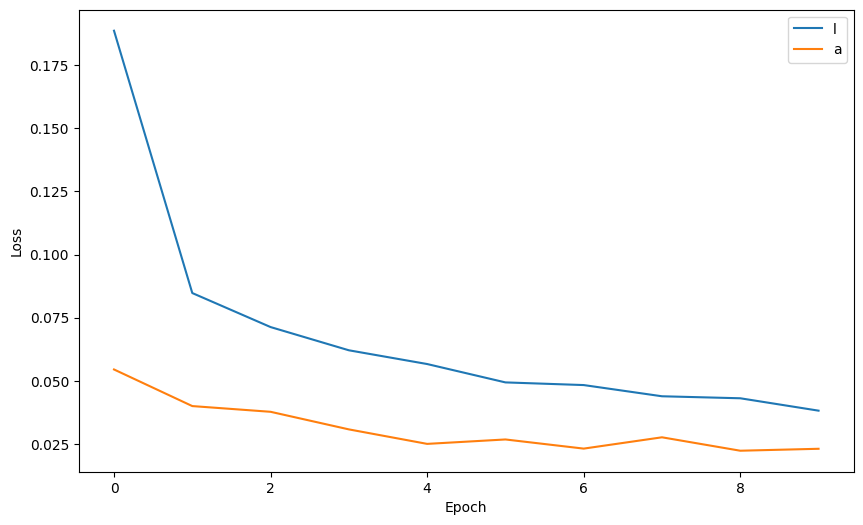

In [43]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss)              # Loss values from DataFrame
plt.plot(summary.val_loss)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend('labels');

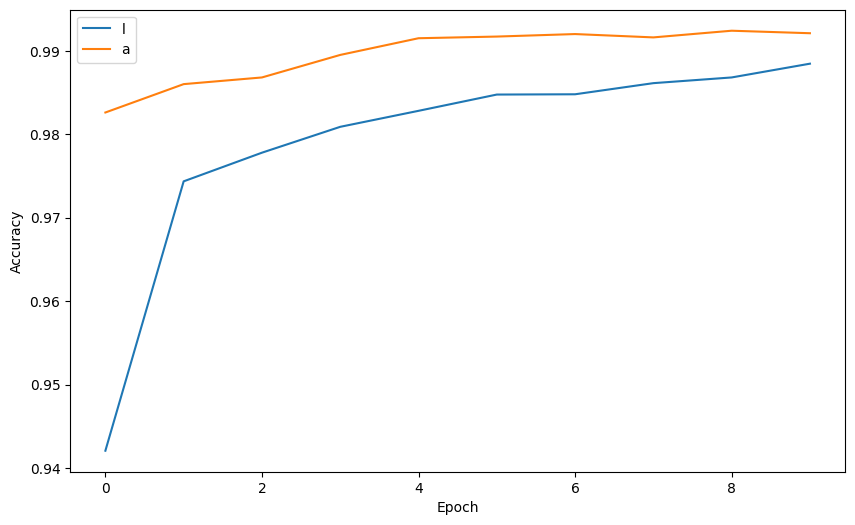

In [44]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy)        # Accuracy scores  from DataFrame
plt.plot(summary.val_accuracy)
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend('labels');

* We **solved overfitting** problem by using **more convolutional layers**. 

## Eval Metrics

After training the model using X_train and Y_train, the X_test and Y_test data are used to evaluate the performance of this learning. The X_test data allows the model to make predictions using the features it learned and compare them to the real labels. The Y_test data is used as the real labels to calculate the correct prediction rate. The model can give an idea of how well it can perform on new data that it has never seen before based on its performance on the X_test data.

In [45]:
# Loss and Accuracy
print(model.evaluate(X_test,y_test,verbose=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9901 - loss: 0.0274
[0.023122074082493782, 0.9921000003814697]


The model.evaluate() function calculates the performance of the model on the test set. This function is given the test set data (X_test) and the true labels (y_test) as parameters. The function returns two values: the loss and accuracy rate on the test set.

In [46]:
preds = model.predict(X_test)
preds

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[8.57142126e-08, 1.73069893e-07, 1.45245210e-07, ...,
        9.99996305e-01, 6.04553634e-08, 2.28234376e-06],
       [7.50768834e-07, 7.83707250e-08, 9.99999046e-01, ...,
        7.90751409e-10, 1.23480420e-10, 1.48587596e-08],
       [2.25216041e-07, 9.99984741e-01, 4.56013787e-08, ...,
        1.33350213e-05, 4.52303482e-07, 7.76805678e-08],
       ...,
       [3.80601217e-10, 3.01250687e-08, 1.09875851e-10, ...,
        1.45673866e-07, 2.58705109e-06, 3.52080883e-06],
       [2.02783621e-08, 1.08382892e-09, 7.60056740e-10, ...,
        4.25649571e-10, 3.04372916e-05, 5.19990406e-09],
       [9.57862198e-08, 2.71960032e-09, 1.07043697e-07, ...,
        1.11889199e-10, 1.38126905e-08, 2.70947820e-09]], dtype=float32)

The variable preds is a numpy array containing the class predictions of each image in the test dataset predicted by our model. That is, for each test image, it represents the probabilities of the class predicted by our model.

In [47]:
preds[0]

array([8.5714213e-08, 1.7306989e-07, 1.4524521e-07, 8.3851580e-07,
       1.1711678e-07, 7.7621589e-09, 9.0481067e-10, 9.9999630e-01,
       6.0455363e-08, 2.2823438e-06], dtype=float32)

9.999964e-01: The estimated probability value of the seven. This value is very strong, which says that there is a 99.9% probability that the number in this picture is 7.

The letter "e" in "9.9999964e-01" represents the exponent symbol in scientific notation, which is used to express the magnitude of a number more compactly.

9.9999964e-01 = 9.9999964*(1/10^1) = 0.99999964

In [48]:
np.argmax(preds[0]) # For transform probs to final result.

np.int64(7)

* **Correct**.

In [49]:
preds[1]

array([7.5076883e-07, 7.8370725e-08, 9.9999905e-01, 4.2251691e-09,
       3.9142374e-09, 2.7094323e-12, 9.8378806e-08, 7.9075141e-10,
       1.2348042e-10, 1.4858760e-08], dtype=float32)

In [50]:
np.argmax(preds[1]) # For transform probs to final result.

np.int64(2)

* **Correct**

In [51]:
predictions= np.argmax(preds, axis=1)
predictions

array([7, 2, 1, ..., 4, 5, 6])

The variable named predictions is assigned the class indices with the highest probability in the numpy array named preds. The parameter axis=1 specifies that the argmax record columns will be matched (i.e. the class probability in each example will be satisfied). As a result, the prediction array contains the class indices with the highest probability for each example in the preds array.

In [52]:
len(predictions)

10000

In [53]:
predictions

array([7, 2, 1, ..., 4, 5, 6])

In [54]:
predictions[0]

np.int64(7)

In [55]:
print(predictions[:300])

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1 3 1 3 4 7 2 7
 1 2 1 1 7 4 2 3 5 1 2 4 4 6 3 5 5 6 0 4 1 9 5 7 8 9 3 7 4 6 4 3 0 7 0 2 9
 1 7 3 2 9 7 7 6 2 7 8 4 7 3 6 1 3 6 9 3 1 4 1 7 6 9 6 0 5 4 9 9 2 1 9 4 8
 7 3 9 7 4 4 4 9 2 5 4 7 6 7 9 0 5 8 5 6 6 5 7 8 1 0 1 6 4 6 7 3 1 7 1 8 2
 0 2 9 9 5 5 1 5 6 0 3 4 4 6 5 4 6 5 4 5 1 4 4 7 2 3 2 7 1 8 1 8 1 8 5 0 8
 9 2 5 0 1 1 1 0 9 0 3 1 6 4 2 3 6 1 1 1 3 9 5 2 9 4 5 9 3 9 0 3 6 5 5 7 2
 2 7 1 2 8 4 1 7 3 3 8 8 7 9 2 2 4 1 5 9 8 7 2 3 0 6 4 2 4 1 9 5 7 7 2 8 2
 6 8 5 7 7 9 1 8 1 8 0 3 0 1 9 9 4 1 8 2 1 2 9 7 5 9 2 6 4 1 5 8 2 9 2 0 4
 0 0 2 8]


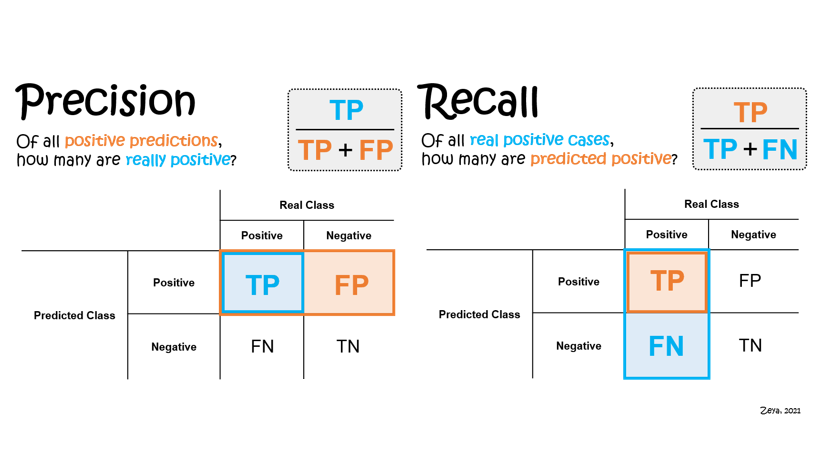

In [56]:
from sklearn.metrics import classification_report,confusion_matrix

In [57]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       1.00      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [58]:
print(confusion_matrix(y_test, predictions))

[[ 976    1    1    0    0    0    1    1    0    0]
 [   0 1132    1    1    0    0    0    1    0    0]
 [   1    2 1020    2    0    0    0    5    2    0]
 [   0    0    0 1008    0    1    0    0    1    0]
 [   0    0    0    0  968    0    4    0    2    8]
 [   2    0    0    6    0  879    3    1    0    1]
 [   3    1    0    0    1    1  952    0    0    0]
 [   0    3    3    0    0    0    0 1019    1    2]
 [   2    0    1    1    0    0    0    1  968    1]
 [   2    1    0    0    1    0    1    3    2  999]]


In [59]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.023122074082493782
Test accuracy: 0.9921000003814697


* **Accuracy** increased **99%**.It was **98%** in "Basic CNN".

# Get Prediction

In [60]:
my_number = X_test[120]

In [61]:
my_number.shape

(28, 28, 1)

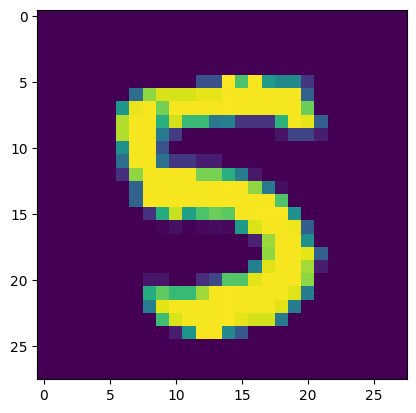

In [62]:
plt.imshow(my_number); 

In [63]:
model.predict(my_number.reshape(1,28,28,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[2.5970690e-08, 1.6809720e-07, 6.8136332e-09, 2.8770128e-05,
        4.0927603e-08, 9.9992943e-01, 2.2159567e-05, 2.1054303e-08,
        3.4801117e-06, 1.5808389e-05]], dtype=float32)

he number 1 at the beginning indicates how many samples the model is processing. Changing this number determines how much data the model will predict.

If you set this number to 5, the model will predict on five separate samples. That is, the model processes five different input samples and produces separate prediction results for each. Therefore, the output will contain five separate prediction results.

model.predict(my_number.reshape(5, 28, 28, 1))

The code above assumes the input sample "my_number" to be five separate samples and runs the model on these five samples. This results in five different prediction results. This allows the model to be run on multiple samples at the same time.


In [64]:
np.argmax(model.predict(my_number.reshape(1,28,28,1)), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([5])

## Save the FINAL Model

In [65]:
model.save("cnn_1_complex.h5")

In [66]:
# We save the model according to the latest update as below.

In [67]:
from tensorflow.keras.saving import save_model
save_model(model, "cnn_1_complex.h5")

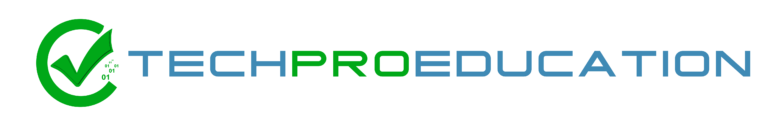

# Get Prediction by Using Saved Model

## Get Prediction by Using Current Data Set

In [68]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import mnist

# Load MNIST data 
(_, _), (X_test, y_test) = mnist.load_data()

# Load the saved model
model = load_model("cnn_1_complex.h5")

# Select an observation and get predict
idx = np.random.randint(0, X_test.shape[0])
sample = X_test[idx]
prediction = model.predict(sample.reshape(1, 28, 28, 1))

# Print the prediction result
print(f"Actual Label: {y_test[idx]}")
print(f"Predicted Label: {np.argmax(prediction)}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Actual Label: 1
Predicted Label: 8


When we run this code block, a random image is selected, given to our model and a prediction is made from our model. As a result, the actual label and the predicted label are printed on the screen.

This code first selects a random sample from X_test, then resizes this sample to fit the model's input shape. It then gets the class prediction of this sample using the predict() function.

## Get Prediction by Using a Sample from Local Computer

In [69]:
from PIL import Image
import numpy as np
import tensorflow as tf

# Open the new image and convert it to a suitable format
image = Image.open(r"eight.JPG").convert('L')

image = image.resize((28, 28))
image_array = np.array(image)
image_array = image_array.reshape(1, 28, 28, 1)

# Load the model and make a prediction
model = tf.keras.models.load_model('cnn_1_complex.h5')
prediction = model.predict(image_array)

# Print the predicted number
print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
8


* **Correct!**

Here the "***convert('L')**" operation makes the image black and white and uses only the pixel's part (brightness) value.

The code **image = image.resize((28, 28))** resizes the representation to 28x28 pixels. This operation provides an input size that matches the model's expectations.

The code **image_array = np.array(image)** converts the representation to a NumPy array. This view can then be processed by the model.

The code **image_array = image_array.reshape(1, 28, 28, 1)** consists of documentation that matches the view model's requirements. More specifically, this image is an array containing a single sample, and this array will represent a representation with dimensions of 28x28 pixels and a grayscale channel.

### Uplad another number

In [70]:
# Open the new image and convert it to a suitable format
image = Image.open(r"two.png").convert('L')

image = image.resize((28, 28))
image_array = np.array(image)
image_array = image_array.reshape(1, 28, 28, 1)

# Load the model and make a prediction
model = tf.keras.models.load_model('cnn_1_complex.h5')
prediction = model.predict(image_array)

# Print the predicted number
print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
8


* **Wrong !**